# BNPL Default Risk: Model Training and Evaluation

## Workflow Overview
This notebook trains and compares two models on the prepared data:

1. Load the cache from `data/processed/final_data.npz`
2. XGBoost baseline as a traditional ML benchmark
3. PyTorch model with entity embeddings and weighted cross-entropy
4. Compare macro F1, confusion matrices, and learning curves

## Key Decisions

### 1. XGBoost as Baseline
XGBoost is strong on tabular data and handles non-linearities, feature interactions, and missing values without extra work. It gives a solid benchmark to compare the neural network against. I use `compute_sample_weight(class_weight='balanced')` to deal with the class imbalance, which is roughly 88 percent Low, 6.8 percent Medium, and 5.2 percent High.

### 2. PyTorch with Entity Embeddings
One hot encoding treats categories as equally distant from each other. Electronics is as far from Fashion as it is from Travel. Entity embeddings learn dense vectors where similar categories end up closer together. For this dataset, Employment Status and Shopping Category likely have relationships that matter. Unemployed is probably closer to Student than to Employed in terms of default behaviour, and embeddings can capture that. One hot cannot.

### 3. Weighted Cross-Entropy instead of Focal Loss
I tried Focal Loss with gamma 1.0 and 2.0 first. Weighted Cross-Entropy came out ahead on macro F1. Focal Loss with gamma 1.0 was close but less stable for this imbalance level.

Macro F1 treats each class equally, so the model is penalised if it ignores Medium or High risk. That matches the goal here. Catching defaults matters more than getting the Low risk majority right.

### 4. Early Stopping
The sample is small enough for the network to memorise noise. Patience of 15 lets validation F1 improve for a while before stopping when it plateaus.

### 5. CUDA
The notebook detects CUDA and uses it when available, falling back to CPU otherwise.

### Imports and Configuration
Setting the working directory to the project root, checking that `data/processed/final_data.npz` exists, and importing the utilities.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
import torch
%matplotlib inline

import notebook_utils as N
import utils as U
from config import DATA_PATH, TARGET_NAMES

N.verify_cache(DATA_PATH)

Cache found. Proceeding.


### Load Processed Data
Loading the processed arrays from cache. This includes the scaled numeric features, the encoded categoricals, and the encoded target labels.

In [2]:
data = U.load_processed_data('../data/processed/final_data.npz')
X_train = data['X_train']
X_test  = data['X_test']
cat_train = data['cat_train']
cat_test  = data['cat_test']
y_train = data['y_train']
y_test  = data['y_test']
cat_cardinalities = data['cat_cardinalities']
target_names = ['Low', 'Medium', 'High']

# Encode target labels
y_train_enc = U.encode_target(y_train)
y_test_enc  = U.encode_target(y_test)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"cat_train: {cat_train.shape}, cat_test: {cat_test.shape}")
print(f"y_train: {y_train_enc.shape}, y_test: {y_test_enc.shape}")

X_train: (7000, 7), X_test: (1500, 7)
cat_train: (7000, 3), cat_test: (1500, 3)
y_train: (7000,), y_test: (1500,)


### XGBoost Baseline
Training XGBoost with balanced sample weights. This gives a robust, interpretable benchmark to compare against the PyTorch model.

XGBoost Performance on Test Set:
              precision    recall  f1-score   support

         Low     0.9767    0.9508    0.9635      1320
      Medium     0.4191    0.5588    0.4790       102
        High     0.8101    0.8205    0.8153        78

    accuracy                         0.9173      1500
   macro avg     0.7353    0.7767    0.7526      1500
weighted avg     0.9301    0.9173    0.9229      1500

Macro F1-Score: 0.7526


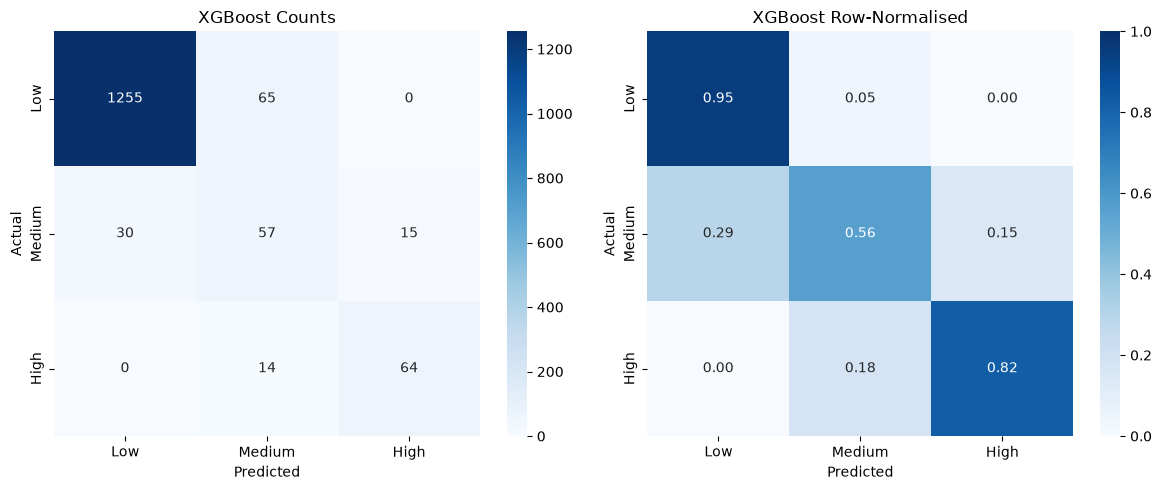

In [3]:
xgb_model, y_pred_xgb, xgb_macro_f1 = N.run_xgboost_baseline(
    X_train, y_train_enc, X_test, y_test_enc
)
plt.show()

### Reproducibility
Before training, I seed Python, NumPy, and PyTorch so repeated runs give the same result. Without this, DataLoader shuffling and weight initialisation drift between runs and the reported macro F1 moves by a point or two each time. The scripts in `src/` already call the same seed through `set_seed`, so this just matches that behaviour in the notebook.

In [4]:
import random
from config import RANDOM_STATE

SEED = RANDOM_STATE
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Seeded with {SEED}")

Seeded with 42


### Prepare PyTorch DataLoaders
Wrapping the numeric and categorical features into a `TabularDataset` and building the train and test loaders. Batch size of 256 balances memory use and gradient stability.

In [5]:
from torch.utils.data import DataLoader

batch_size = 256
train_ds = U.TabularDataset(X_train, cat_train, y_train_enc)
test_ds  = U.TabularDataset(X_test,  cat_test,  y_test_enc)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

### Define Model and Optimizer
The model is `EmbeddingNet`: entity embeddings of size 8 per categorical feature, concatenated with the numeric features, then two dense layers of 128 and 64 with BatchNorm and Dropout at 0.4.

Class weights are inverse frequency, normalised to sum to 3, so each class contributes roughly equally to the loss.

Optimizer is Adam with weight decay. The scheduler is ReduceLROnPlateau in max mode, which lowers the learning rate when validation F1 stops improving.

In [6]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = U.EmbeddingNet(num_numeric=X_train.shape[1], cat_cardinalities=cat_cardinalities)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Class weights for CrossEntropy
class_counts = np.bincount(y_train_enc)
class_weights = torch.tensor([1.0/(c + 1e-6) for c in class_counts], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 3

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

Using device: cuda
Model parameters: 13,043


### Train PyTorch Model
The training loop computes loss, updates weights, validates each epoch, keeps the best model based on validation macro F1, and stops early when F1 has not improved for 15 epochs. Training history is stored for plotting.

In [7]:
model, train_losses, val_losses, val_f1s = U.train_model(
    model, train_loader, test_loader, criterion, optimizer, scheduler,
    device, epochs=200, patience=15
)

Epoch  10/200 | Train 0.3127 | Val 0.2336 | Val F1 0.8015 | LR 1.00e-03
Epoch  20/200 | Train 0.2500 | Val 0.1891 | Val F1 0.8230 | LR 1.00e-03
Epoch  30/200 | Train 0.2083 | Val 0.1859 | Val F1 0.8240 | LR 5.00e-04
Epoch  40/200 | Train 0.2030 | Val 0.1881 | Val F1 0.8455 | LR 1.25e-04
Epoch  50/200 | Train 0.1935 | Val 0.1851 | Val F1 0.8331 | LR 6.25e-05
Early stop at epoch 55


### PyTorch Final Evaluation
Evaluating the best saved model on the test set. The confusion matrix shows where the model makes mistakes. I expect it to catch High risk well but to have lower precision on Medium risk, since that class sits between the other two.

PyTorch Performance on Test Set:
              precision    recall  f1-score   support

         Low     0.9976    0.9379    0.9668      1320
      Medium     0.5111    0.9020    0.6525       102
        High     0.9114    0.9231    0.9172        78

    accuracy                         0.9347      1500
   macro avg     0.8067    0.9210    0.8455      1500
weighted avg     0.9600    0.9347    0.9429      1500

Macro F1-Score: 0.8455


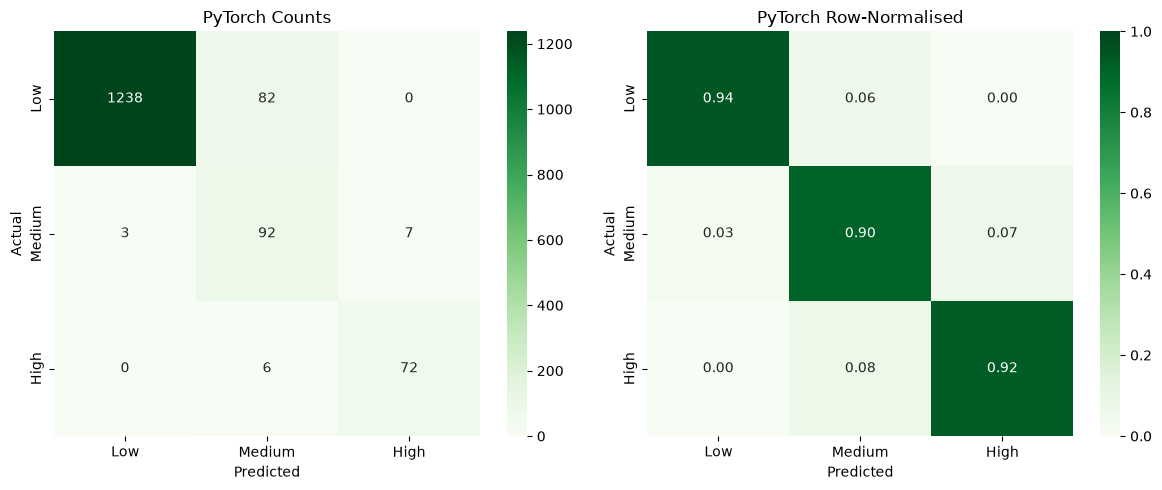

In [8]:
pytorch_f1, preds, targets = N.run_pytorch_evaluation(
    model, test_loader, device
)
plt.show()

### Learning Curves and Comparison
The loss curves show the validation loss settling after a small number of epochs. The macro F1 curve on the right shows the model improving and then holding steady. The red dashed line is the XGBoost baseline, which the PyTorch model ends up beating.

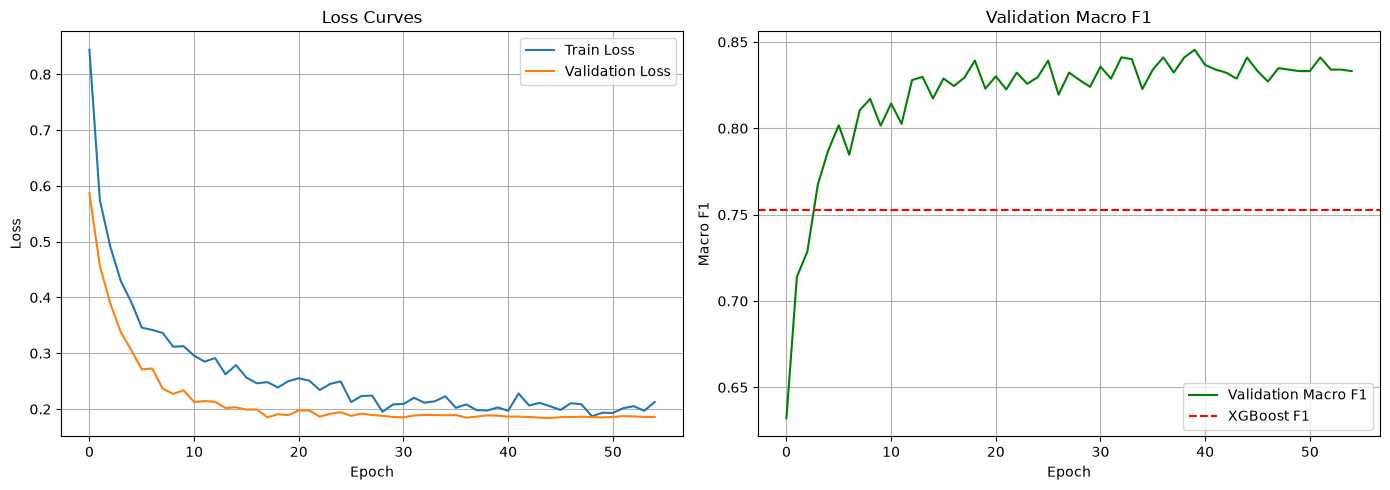

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(14,5))
N.plot_loss_f1(train_losses, val_losses, val_f1s, xgb_baseline=xgb_macro_f1, axs=axs)
plt.tight_layout()
plt.show()

### Final Comparison
Printing the macro F1 scores side by side. The gap shows what entity embeddings and weighted cross-entropy add over the XGBoost baseline on this dataset.

In [10]:
print(f"XGBoost  Macro F1: {xgb_macro_f1:.4f}")
print(f"PyTorch  Macro F1: {pytorch_f1:.4f}")
print(f"Improvement:       {pytorch_f1 - xgb_macro_f1:+.4f}")

XGBoost  Macro F1: 0.7526
PyTorch  Macro F1: 0.8455
Improvement:       +0.0929
